# Offline Replay with Selective Potentiation of States 1–7 — T-maze (13_T_two_feats)

Loads the CA3 recurrent weight matrix after **lap 10** from each of the 10 T-maze trials
(`Tmaze0`–`Tmaze9`) in `/data/suheecho/BTSP/13_T_two_feats/files`.

Before running the offline simulation a **5 % potentiation** is applied to every existing
recurrent CA3 synapse whose *both* pre- and post-synaptic neurons have place fields in
**states 1–7 (1-indexed, 0-indexed: 0–6)**.  Synapses involving neurons in states 8–10
(0-indexed: 7–9, the right arm of the T) are left unchanged.

A Poisson cue is then injected at **state 1 (1-indexed, 0-indexed: 0)** neurons (top of
the stem) and the network runs for 5 000 ms.

**Hypothesis:** Selective potentiation of the state-1–7 pathway causes the replayed
trajectory to preferentially follow that path (stem → left arm, states 0–6) rather than
the non-potentiated right arm (states 7–9).

**Data generation** (potentiated + control CA3-only replay for all 10 trials) now lives in
`generate_data.ipynb` (`run_offline.simulate_potentiated_replay`, using
`run_offline.ca3_offline_simulation` and `Tmaze_functions.build_potentiated_weight_matrix`).
This notebook only loads the saved `.npz` outputs and analyses/plots them.


In [1]:
import os, sys, pickle, warnings
import numpy as np
warnings.filterwarnings('ignore')

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ── paths ─────────────────────────────────────────────────────────────────────────────────────────────────────────────
CODE_DIR = os.path.dirname(os.path.abspath("__file__"))
FUNC_DIR = os.path.join(CODE_DIR, "functions")
DATA_DIR = "/data/suheecho/BTSP/13_T_two_feats/files"

sys.path.insert(0, FUNC_DIR)

print("Imports OK")


Imports OK


In [2]:
# ── T-maze layout (matches Tmaze_variables.py) ──────────────────────────────
num_states      = 10
num_CA3_neurons = num_states * 400    # cell_per_unit = 400

state_position = np.array([
    [3.5, 3.5],   # state 0  (1-indexed: 1)  — stem top
    [2.5, 3.5],   # state 1  (1-indexed: 2)  — stem mid
    [1.5, 3.5],   # state 2  (1-indexed: 3)  — stem bottom
    [0.5, 0.5],   # state 3  (1-indexed: 4)  — left-arm end
    [0.5, 1.5],   # state 4  (1-indexed: 5)
    [0.5, 2.5],   # state 5  (1-indexed: 6)
    [0.5, 3.5],   # state 6  (1-indexed: 7)  — horizontal junction
    [0.5, 4.5],   # state 7  (1-indexed: 8)  — right-arm start  [NOT potentiated]
    [0.5, 5.5],   # state 8  (1-indexed: 9)                      [NOT potentiated]
    [0.5, 6.5],   # state 9  (1-indexed: 10) — right-arm end     [NOT potentiated]
])

# ── potentiation: states 1-7 (1-indexed) = 0-6 (0-indexed) ───────────────
POTENTIATED_STATES   = list(range(7))     # 0-indexed: 0..6  (used for weight scaling)
UNPOTENTIATED_STATES = list(range(7, 10)) # 0-indexed: 7, 8, 9
POTENTIATION_FACTOR  = 1.15              # +10 % on existing synapses

# ── comparison arms (exclude shared stem and junction) ──────────────────────
# Left arm  (potentiated, 1-indexed 4-6) = 0-indexed 3,4,5
# Right arm (non-potentiated, 1-indexed 8-10) = 0-indexed 7,8,9
LEFT_ARM_STATES  = [3, 4, 5]   # 0-indexed; 1-indexed: 4, 5, 6
RIGHT_ARM_STATES = [7, 8, 9]   # 0-indexed; 1-indexed: 8, 9, 10

# ── cue: state 1 (1-indexed) = state 0 (0-indexed) — stem top ─────────────────
CUE_STATE_1IDX = 1
CUE_STATE      = CUE_STATE_1IDX - 1     # 0-indexed = 0

# ── simulation duration (matches the offline replay run in generate_data.ipynb) ─────
sim_duration = 20000    # ms

# ── trial directories ───────────────────────────────────────────────
N_TRIALS   = 10
trial_dirs = [os.path.join(DATA_DIR, "Tmaze%d" % i) for i in range(N_TRIALS)]

print(f"Potentiation factor: {POTENTIATION_FACTOR}  (+{(POTENTIATION_FACTOR-1)*100:.0f} %)")
print(f"Potentiated states (0-indexed): {POTENTIATED_STATES}")
print(f"Left arm for comparison  (0-indexed): {LEFT_ARM_STATES}  → 1-indexed: 4,5,6")
print(f"Right arm for comparison (0-indexed): {RIGHT_ARM_STATES} → 1-indexed: 8,9,10")
print(f"Cue state (0-indexed): {CUE_STATE}  centre: {state_position[CUE_STATE]}")


Potentiation factor: 1.15  (+15 %)
Potentiated states (0-indexed): [0, 1, 2, 3, 4, 5, 6]
Left arm for comparison  (0-indexed): [3, 4, 5]  → 1-indexed: 4,5,6
Right arm for comparison (0-indexed): [7, 8, 9] → 1-indexed: 8,9,10
Cue state (0-indexed): 0  centre: [3.5 3.5]


In [3]:
def get_state_neuron_ids(PF_dict, state_0idx):
    """
    Return IDs of neurons whose place-field centre falls within `state_0idx`.
    Uses ±0.5 unit window around state_position[state_0idx].
    """
    c = state_position[state_0idx]
    return np.array(
        sorted(nid for nid, pos in PF_dict.items()
               if abs(pos[0] - c[0]) < 0.5 and abs(pos[1] - c[1]) < 0.5),
        dtype=int,
    )


def assign_state(neuron_id, PF_dict):
    """Return the 0-indexed state whose centre is closest to neuron_id's PF."""
    if neuron_id not in PF_dict:
        return -1
    pos   = np.array(PF_dict[neuron_id])
    dists = np.linalg.norm(state_position - pos, axis=1)
    return int(np.argmin(dists))


# colour scheme: green = left arm (potentiated exclusive), red = right arm (non-potentiated),
#                grey = shared path (stem + junction), orange dashed = cue
def bar_color(s):
    if s in LEFT_ARM_STATES:  return "steelblue"
    if s in RIGHT_ARM_STATES: return "tomato"
    return "lightgrey"

print("Helper functions defined")


Helper functions defined


## Load simulation results for all 10 T-maze trials

Generated by `generate_data.ipynb` (`run_offline.simulate_potentiated_replay`); see the note at the top of this notebook.


## Analysis: left arm (states 4–6, potentiated) vs. right arm (states 8–10, non-potentiated)

In [ ]:
from tqdm import tqdm
results = []
for trial in tqdm(range(N_TRIALS),desc="Trial: "):
    exp_dir = trial_dirs[trial]
    with open(os.path.join(exp_dir, "PF_peak_data.pkl"), "rb") as f:
        PF_dict = pickle.load(f)
    temp_f = dict(np.load(os.path.join(exp_dir, "CA3_replay_potentiated_states1to7_cue1.npz")))
    results.append({
        "spike_times":     temp_f["spike_times_CA3_PC"],
        "spiking_neurons": temp_f["spiking_neurons_CA3_PC"],
        "rate":            temp_f["rate_CA3_PC"],
        "PF_dict":         PF_dict
    })


Trial: 100%|██████████| 10/10 [00:00<00:00, 44.99it/s]


## Control simulation results — original (non-potentiated) weights

Identical setup to the potentiated run, but **no weight scaling** was applied.
Generated together with the potentiated run by `generate_data.ipynb`
(`run_offline.simulate_potentiated_replay`) and saved to `CA3_replay_ctrl_cue1.npz`
inside each trial directory.


## Juxtaposed raster: potentiated (top) vs. control (bottom)

Loaded from saved `.npz` files.
**x-axis** = time (ms); **y-axis** = place cell ID sorted by state order (0→9),
within each state sorted by PF column position.
Horizontal dashed lines mark state boundaries; colours indicate arm membership.

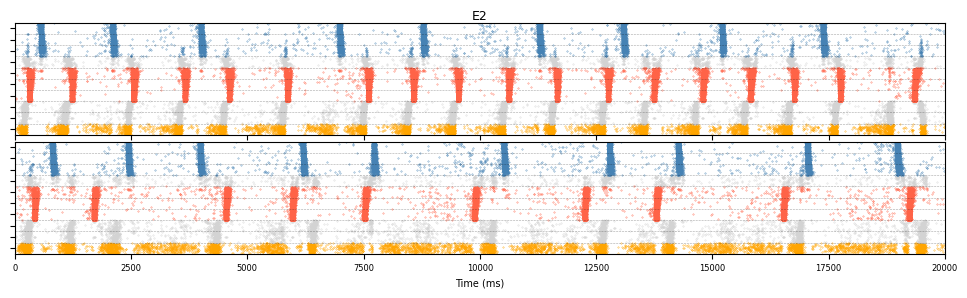

Saved → tmaze_juxtaposed_rasters_trial2.pdf


<Figure size 640x480 with 0 Axes>

In [9]:
targ_trial = 2

CELL_PER_UNIT = 400   # matches global_variables.cell_per_unit

state_y_bounds_wu = [(s * CELL_PER_UNIT, (s + 1) * CELL_PER_UNIT)
                     for s in range(num_states)]  # 8 states

fig7_2, axes7_2 = plt.subplots(
    2, 1,
    figsize=(12, 3),
    sharey=True,
    gridspec_kw={"hspace": 0.06, "wspace": 0.05},
)

trial_idx = targ_trial; exp_dir = trial_dirs[trial_idx]

for row, fname in enumerate(COND_FILES):
    ax = axes7_2[row]

    d          = np.load(os.path.join(exp_dir, fname), allow_pickle=True)
    spike_t    = d["spike_times_CA3_PC"]           # ms
    spike_nids = d["spiking_neurons_CA3_PC"].astype(int)
    states_v   = np.array([state_from_nid(n) for n in spike_nids])

    for s in range(num_states):
        mask = states_v == s
        if mask.any():
            ax.scatter(
                spike_t[mask], spike_nids[mask],
                s=0.3, c=state_color(s), rasterized=True, marker='.',
                zorder=2 if s in LEFT_ARM_STATES + RIGHT_ARM_STATES else 1,
            )

    # state boundary lines
    for y0, _ in state_y_bounds_wu:
        ax.axhline(y0, color="black", linewidth=0.4, linestyle="--", alpha=0.35)

    ax.set_xlim(0, sim_duration)
    ax.set_ylim(0, num_CA3_neurons)
    ax.tick_params(axis="x", labelsize=6)

    if row == 0:
        ax.set_title(f"E{trial_idx}", fontsize=9, pad=2)
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Time (ms)", fontsize=7)

    if trial_idx == 0:
        ax.set_ylabel(ROW_TITLES[row] + "\nneuron ID", fontsize=8)
    else:
        ax.tick_params(labelleft=False)

# ── ytick labels — set once after loop so sharey doesn't wipe them ────────────
ytick_pos_wu = [(y0 + y1) / 2 for y0, y1 in state_y_bounds_wu]
for row in range(2):
    ax0 = axes7_2[row]
    ax0.set_yticks(ytick_pos_wu)
    ax0.set_yticklabels([f"S{s+1}" for s in range(num_states)], fontsize=6)
    for tick, s in zip(ax0.get_yticklabels(), range(num_states)):
        tick.set_color(state_color(s))

plt.show()
plt.savefig(os.path.join(DATA_DIR, "tmaze_juxtaposed_rasters_trial%d.pdf" % targ_trial),
            bbox_inches="tight")

print("Saved → tmaze_juxtaposed_rasters_trial%d.pdf" % targ_trial)

## Average firing rate: potentiated pathway vs. right arm (mirrors `wu_offline_fatigued.ipynb` cell 13)

**Panel 1** — potentiated run only: mean firing rate of neurons in the potentiated
pathway (stem + left arm + junction, states 1–7 1-indexed) vs. the non-potentiated
right arm (states 8–10), normalized to spikes per neuron per second.

**Panel 2** — potentiated-pathway (states 1–7) firing rate **without** (control) vs.
**with** potentiation, paired by trial (same weight-matrix seed) and connected with lines.


### Supple. Fig. c and d

In [16]:
# ── Figure: average firing rate comparison (mirrors wu_offline_fatigued.ipynb cell 13) ──
from scipy import stats
from stat_functions import cohens_d_paired, ci_paired

fig, axs = plt.subplots(1, 2, figsize=(5, 3))

left_rate_all   = np.zeros(N_TRIALS)   # left arm + stem (states 1-7) rate — potentiated run
right_rate_all = np.zeros(N_TRIALS)   # right arm (states 8-10) rate  — potentiated run

# ── Panel 1: left arm+stem vs. right arm (potentiated run only) ─────────────
ax = axs[0]
for trial_idx in range(N_TRIALS):
    r          = results[trial_idx]
    PF_dict    = r["PF_dict"]
    spike_nids = r["spiking_neurons"].astype(int)

    counts = np.zeros(num_states, dtype=int)
    for nid in spike_nids:
        s = assign_state(nid, PF_dict)
        if 0 <= s < num_states:
            counts[s] += 1

    left_rate_all[trial_idx]   = counts[LEFT_ARM_STATES].sum()   / (400 * len(LEFT_ARM_STATES)   * sim_duration / 1000)
    right_rate_all[trial_idx] = counts[RIGHT_ARM_STATES].sum() / (400 * len(RIGHT_ARM_STATES) * sim_duration / 1000)

jitter = 0.04 * (np.random.default_rng(7).random(N_TRIALS) - 0.5)
ax.scatter(np.zeros(N_TRIALS) + jitter, right_rate_all, color="steelblue",      s=40, zorder=3)
ax.scatter(np.ones(N_TRIALS)  + jitter, left_rate_all,   color="tomato", s=40, zorder=3)
for i in range(N_TRIALS):
    ax.plot([jitter[i], 1 + jitter[i]], [right_rate_all[i], left_rate_all[i]],
            color="lightgrey", linewidth=0.8, zorder=1)
ax.errorbar([0, 1],
            [right_rate_all.mean(), left_rate_all.mean()],
            yerr=[right_rate_all.std() / np.sqrt(N_TRIALS),
                  left_rate_all.std()   / np.sqrt(N_TRIALS)],
            fmt="D", color="black", markersize=8, capsize=5, zorder=5)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Right arm", "Left arm"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 3); ax.set_yticks(np.arange(0, 3.1, 1))
ax.set_ylabel("Firing rate")
ax.set_title("Left arm vs. right arm (potentiated run)", fontsize=10)

# ── Panel 2: left arm+stem rate, control vs. potentiated ────────────────────
ax = axs[1]

left_rate_ctrl = np.full(N_TRIALS, np.nan)
for trial_idx in range(N_TRIALS):
    trial_dir = trial_dirs[trial_idx]
    ctrl_path = os.path.join(trial_dir, "CA3_replay_ctrl_cue1.npz")
    if not os.path.exists(ctrl_path):
        continue
    PF_dict    = results[trial_idx]["PF_dict"]
    ctrl_data  = np.load(ctrl_path, allow_pickle=True)
    spike_nids = ctrl_data["spiking_neurons_CA3_PC"].astype(int)

    counts = np.zeros(num_states, dtype=int)
    for nid in spike_nids:
        s = assign_state(nid, PF_dict)
        if 0 <= s < num_states:
            counts[s] += 1

    left_rate_ctrl[trial_idx] = counts[LEFT_ARM_STATES].sum() / (400 * len(LEFT_ARM_STATES) * sim_duration / 1000)

ax.scatter(np.zeros(N_TRIALS) + jitter, left_rate_ctrl, color="grey",      s=40, zorder=3)
ax.scatter(np.ones(N_TRIALS)  + jitter, left_rate_all,  color="tomato", s=40, zorder=3)
for i in range(N_TRIALS):
    ax.plot([jitter[i], 1 + jitter[i]], [left_rate_ctrl[i], left_rate_all[i]],
            color="lightgrey", linewidth=0.8, zorder=1)
ax.errorbar([0, 1],
            [np.nanmean(left_rate_ctrl), left_rate_all.mean()],
            yerr=[np.nanstd(left_rate_ctrl) / np.sqrt(N_TRIALS),
                  left_rate_all.std()        / np.sqrt(N_TRIALS)],
            fmt="D", color="black", markersize=8, capsize=5, zorder=5)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Control", "Potentiated"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 3); ax.set_yticks(np.arange(0, 3.1, 1))
ax.set_ylabel("Firing rate")
ax.set_title("Potentiated vs. Not", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "tmaze_FR_comparison.svg"), format="svg",
            bbox_inches="tight")
plt.show()

# ── Stats ────────────────────────────────────────────────────────────────────
metrics = [
    ("Left arm vs. right arm (pot. run)", left_rate_all, right_rate_all),
    ("Left arm: ctrl vs. potentiated",     left_rate_ctrl,  left_rate_all),
]

for label, x, y in metrics:
    mask = ~(np.isnan(x) | np.isnan(y))
    xm, ym = x[mask], y[mask]
    t_stat, p_val = stats.ttest_rel(xm, ym)
    d_z = cohens_d_paired(xm, ym)
    ci_lo, ci_hi = ci_paired(xm, ym)
    print(f"{label:36s}: {xm.mean():.3f}±{xm.std(ddof=1):.3f}  vs  "
          f"{ym.mean():.3f}±{ym.std(ddof=1):.3f}  "
          f"t={t_stat:.3f}  p={p_val:.10f}  d_z={d_z:.3f}  CI=[{ci_lo:.3f}, {ci_hi:.3f}]")


Left arm vs. right arm (pot. run)   : 1.969±0.571  vs  0.806±0.316  t=8.346  p=0.0000157593  d_z=2.639  CI=[0.848, 1.479]
Left arm: ctrl vs. potentiated      : 1.036±0.353  vs  1.969±0.571  t=-10.462  p=0.0000024539  d_z=-3.308  CI=[-1.136, -0.732]


In [ ]:
# ── replay detection helpers (refined: per-region burst detection) ────────────
from scipy.ndimage import gaussian_filter1d
from scipy import stats

def smooth_rate(rate_arr, dt_ms, sigma_ms=20.0):
    return gaussian_filter1d(rate_arr, sigma=sigma_ms / dt_ms)


def detect_burst_intervals(rate_smooth, times_ms,
                           threshold, min_dur_ms=70, min_gap_ms=50):
    """Return list of (t_start_ms, t_end_ms) for contiguous bursts above threshold."""
    above = rate_smooth > threshold
    if not above.any():
        return []
    changes = np.diff(above.astype(int))
    on_idx  = np.where(changes ==  1)[0] + 1
    off_idx = np.where(changes == -1)[0] + 1
    if above[0]:  on_idx  = np.concatenate([[0],            on_idx])
    if above[-1]: off_idx = np.concatenate([off_idx, [len(times_ms) - 1]])

    intervals = []
    for si, ei in zip(on_idx, off_idx):
        t0, t1 = times_ms[si], times_ms[ei]
        if t1 - t0 < min_dur_ms:
            continue
        if intervals and t0 - intervals[-1][1] < min_gap_ms:
            intervals[-1] = (intervals[-1][0], t1)   # merge
        else:
            intervals.append((t0, t1))
    return intervals


# ── region definitions ──────────────────────────────────────────────────────
# Each region's neurons vary systematically along ONE axis of PF_dict's
# [row, col] position; the other axis is shared/constant within the region.
#   stem      (S1-3, 0-idx 0-2): row varies,    column constant (3.5)
#   left arm  (S4-6, 0-idx 3-5): column varies, row constant (0.5)
#   right arm (S8-10, 0-idx 7-9): column varies, row constant (0.5)
STEM_STATES = [0, 1, 2]   # 0-indexed; 1-indexed: 1, 2, 3

REGION_DEFS = {
    "stem":  {"states": STEM_STATES,      "axis": 0},   # 0 = row
    "left":  {"states": LEFT_ARM_STATES,  "axis": 1},   # 1 = column
    "right": {"states": RIGHT_ARM_STATES, "axis": 1},
}


def get_region_neuron_ids(PF_dict, states):
    """Union of neuron IDs whose place field lies in any of `states`."""
    ids = np.concatenate([get_state_neuron_ids(PF_dict, s) for s in states])
    return np.unique(ids)


def region_population_rate(spike_t_ms, spike_nids, region_nids, duration_ms, bin_ms=1.0):
    """Binned, per-neuron population rate (Hz), built only from `region_nids` spikes."""
    bins         = np.arange(0, duration_ms + bin_ms, bin_ms)
    in_region    = np.isin(spike_nids, region_nids)
    spk_count, _ = np.histogram(spike_t_ms[in_region], bins=bins)
    rate_hz      = spk_count / (max(len(region_nids), 1) * (bin_ms / 1000))
    times_ms     = bins[:-1] + bin_ms / 2
    return rate_hz, times_ms


def classify_arm_direction(burst_spike_t, burst_pos, r_thresh=0.15, min_spikes=5):
    """
    Pearson r between spike time and PF position along the region's own axis
    (row for the stem, column for the arms).  A burst is a *valid replay
    event* for that region when |r| exceeds `r_thresh`, i.e. spikes progress
    systematically along the region rather than firing without sequential
    structure.
    """
    valid = burst_pos >= 0
    if valid.sum() < min_spikes:
        return False
    r = np.corrcoef(burst_spike_t[valid], burst_pos[valid])[0, 1]
    return (not np.isnan(r)) and (abs(r) > r_thresh)


def count_region_replay_events(spike_t_ms, spike_nids, PF_dict, states, axis,
                               duration_ms, bin_ms=1.0, sigma_ms=20,
                               thresh_factor=0.5, min_dur_ms=50, min_gap_ms=50,
                               r_thresh=0.1, min_spikes=5):
    """
    Isolate spikes from neurons whose place field lies in `states`, detect
    burst intervals in that subpopulation's own rate, and keep the bursts
    that pass the sequential-correlation check (valid replay events).

    Returns
    -------
    n_valid   : int, number of valid replay events
    n_bursts  : int, number of detected burst intervals (before validity check)
    intervals : list of (t0, t1) for the valid replay events
    """
    region_nids        = get_region_neuron_ids(PF_dict, states)
    rate_arr, times_ms = region_population_rate(spike_t_ms, spike_nids,
                                                 region_nids, duration_ms, bin_ms)
    rate_sm   = smooth_rate(rate_arr, bin_ms, sigma_ms)
    threshold = rate_sm.mean() + thresh_factor * rate_sm.std()
    bursts    = detect_burst_intervals(rate_sm, times_ms, threshold, min_dur_ms, min_gap_ms)

    in_region  = np.isin(spike_nids, region_nids)
    region_t   = spike_t_ms[in_region]
    region_pos = np.array([PF_dict.get(int(n), [-1, -1])[axis] for n in spike_nids[in_region]])

    valid_intervals = []
    for t0, t1 in bursts:
        mask = (region_t >= t0) & (region_t <= t1)
        if mask.sum() < min_spikes:
            continue
        if classify_arm_direction(region_t[mask], region_pos[mask], r_thresh, min_spikes):
            valid_intervals.append((t0, t1))
    return len(valid_intervals), len(bursts), valid_intervals


def count_replay_by_region(spike_t_ms, spike_nids, PF_dict, duration_ms, **kwargs):
    """Run count_region_replay_events separately for stem, left arm, and right arm."""
    counts, n_bursts, intervals = {}, {}, {}
    for region, spec in REGION_DEFS.items():
        n_valid, nb, ivals = count_region_replay_events(
            spike_t_ms, spike_nids, PF_dict, spec["states"], spec["axis"],
            duration_ms, **kwargs
        )
        counts[region]    = n_valid
        n_bursts[region]  = nb
        intervals[region] = ivals
    return counts, n_bursts, intervals


def merge_close_events(intervals, merge_gap_ms=30):
    """
    Merge a list of (t0, t1) intervals so that any two whose gap (start of
    the later one minus end of the earlier one) is < merge_gap_ms collapse
    into a single event.
    """
    if not intervals:
        return []
    ordered = sorted(intervals, key=lambda iv: iv[0])
    merged  = [ordered[0]]
    for t0, t1 in ordered[1:]:
        last_t0, last_t1 = merged[-1]
        if t0 - last_t1 < merge_gap_ms:
            merged[-1] = (last_t0, max(last_t1, t1))
        else:
            merged.append((t0, t1))
    return merged


def count_total_replay_events(region_intervals, merge_gap_ms=30):
    """
    Combine the valid replay-event intervals detected separately in the
    stem, left-arm, and right-arm populations.  A single physical replay
    that sweeps across regions (e.g. stem -> left arm) gets detected once
    per region, so events starting within `merge_gap_ms` of another
    region's event are merged and counted as ONE big replay event.

    Parameters
    ----------
    region_intervals : dict of {region: [(t0, t1), ...]}, e.g. the
                       `intervals` dict returned by count_replay_by_region.

    Returns
    -------
    n_total : int, number of merged replay events
    merged  : list of (t0, t1) for the merged events
    """
    all_intervals = []
    for ivals in region_intervals.values():
        all_intervals.extend(ivals)
    merged = merge_close_events(all_intervals, merge_gap_ms)
    return len(merged), merged


# ── loop over both conditions ─────────────────────────────────────────────────
COND_LABELS_TMAZE = ["Control", "Potentiated"]
COND_FILES_TMAZE  = ["CA3_replay_ctrl_cue1.npz",
                      "CA3_replay_potentiated_states1to7_cue1.npz"]

region_labels        = ["stem", "left", "right"]
replay_region_counts = np.zeros((2, N_TRIALS, 3), dtype=int)
replay_total_events  = np.zeros((2, N_TRIALS), dtype=int)
MERGE_GAP_MS         = 30

for cond_idx, (cond_label, fname) in enumerate(zip(COND_LABELS_TMAZE, COND_FILES_TMAZE)):
    print(f"\n=== {cond_label} ===")
    for trial_idx in range(N_TRIALS):
        trial_dir = trial_dirs[trial_idx]

        d          = np.load(os.path.join(trial_dir, fname), allow_pickle=True)
        spike_t    = d["spike_times_CA3_PC"]           # ms
        spike_nids = d["spiking_neurons_CA3_PC"].astype(int)

        with open(os.path.join(trial_dir, "PF_peak_data.pkl"), "rb") as f:
            PF_dict = pickle.load(f)

        counts, n_bursts, intervals = count_replay_by_region(spike_t, spike_nids, PF_dict, sim_duration)
        for ri, rlabel in enumerate(region_labels):
            replay_region_counts[cond_idx, trial_idx, ri] = counts[rlabel]

        n_total, merged_intervals = count_total_replay_events(intervals, MERGE_GAP_MS)
        replay_total_events[cond_idx, trial_idx] = n_total

        print(f"  Tmaze{trial_idx}: bursts(stem/left/right)="
              f"{n_bursts['stem']}/{n_bursts['left']}/{n_bursts['right']}  "
              f"valid events — stem={counts['stem']}  left={counts['left']}  right={counts['right']}  "
              f"| merged total={n_total}")

print("\nDone.")
# print("\nStem  counts — control:    ", replay_region_counts[0, :, 0])
# print("Stem  counts — potentiated:", replay_region_counts[1, :, 0])
# print("Left  counts — control:    ", replay_region_counts[0, :, 1])
# print("Left  counts — potentiated:", replay_region_counts[1, :, 1])
# print("Right counts — control:    ", replay_region_counts[0, :, 2])
# print("Right counts — potentiated:", replay_region_counts[1, :, 2])
# print("\nMerged total events — control:    ", replay_total_events[0])
# print("Merged total events — potentiated:", replay_total_events[1])



=== Control ===
  Tmaze0: bursts(stem/left/right)=11/10/10  valid events — stem=11  left=10  right=6  | merged total=26
  Tmaze1: bursts(stem/left/right)=11/9/12  valid events — stem=11  left=9  right=10  | merged total=29
  Tmaze2: bursts(stem/left/right)=12/10/10  valid events — stem=11  left=9  right=10  | merged total=28


  Tmaze3: bursts(stem/left/right)=13/10/11  valid events — stem=11  left=10  right=10  | merged total=31
  Tmaze4: bursts(stem/left/right)=12/11/11  valid events — stem=6  left=11  right=11  | merged total=26
  Tmaze5: bursts(stem/left/right)=12/12/11  valid events — stem=9  left=12  right=11  | merged total=32
  Tmaze6: bursts(stem/left/right)=9/10/10  valid events — stem=7  left=10  right=9  | merged total=26
  Tmaze7: bursts(stem/left/right)=8/10/11  valid events — stem=3  left=10  right=6  | merged total=18
  Tmaze8: bursts(stem/left/right)=10/9/11  valid events — stem=7  left=9  right=11  | merged total=24
  Tmaze9: bursts(stem/left/right)=26/1/29  valid events — stem=10  left=1  right=22  | merged total=30

=== Potentiated ===
  Tmaze0: bursts(stem/left/right)=17/17/6  valid events — stem=17  left=4  right=5  | merged total=23
  Tmaze1: bursts(stem/left/right)=18/13/9  valid events — stem=15  left=11  right=7  | merged total=24
  Tmaze2: bursts(stem/left/right)=19/18/9  valid eve

### Supple. Fig. e and f

In [17]:
# ── Figure: total replay count & % replay including left arm (mirrors wu_offline_fatigued.ipynb cell 26) ──
from stat_functions import cohens_d_paired, ci_paired

fig9, axes9 = plt.subplots(1, 2, figsize=(5, 3))

total_ctrl = np.maximum(replay_total_events[0], 1)
total_pot  = np.maximum(replay_total_events[1], 1)

# ── Panel 1: total replay count (merged across stem/left/right) ─────────────
ax = axes9[0]
jitter = 0.04 * (np.random.default_rng(7).random(N_TRIALS) - 0.5)
ax.scatter(np.zeros(N_TRIALS) + jitter, total_ctrl, color="grey",      s=40, zorder=3)
ax.scatter(np.ones(N_TRIALS)  + jitter, total_pot,  color="tomato", s=40, zorder=3)
for i in range(N_TRIALS):
    ax.plot([jitter[i], 1 + jitter[i]], [total_ctrl[i], total_pot[i]],
            color="lightgrey", linewidth=0.8, zorder=1)
ax.errorbar([0, 1],
            [total_ctrl.mean(), total_pot.mean()],
            yerr=[total_ctrl.std() / np.sqrt(N_TRIALS),
                  total_pot.std()  / np.sqrt(N_TRIALS)],
            fmt="D", color="black", markersize=8, capsize=5, zorder=5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Control", "Potentiated"])
ax.set_xlim(-0.5, 1.5); ax.set_ylim(0, 40)
ax.set_ylabel("Replay count")
ax.set_title("Total replay count (merged, <30 ms apart)", fontsize=10)

# ── Panel 2: % replay including left arm, paired scatter ───────────────────
ax = axes9[1]
left_frac_ctrl = np.sum(replay_region_counts[0, :, :2], axis=1) / np.sum(replay_region_counts[0], axis=1)
left_frac_pot  = np.sum(replay_region_counts[1, :, :2], axis=1) / np.sum(replay_region_counts[1], axis=1)

jitter2 = 0.1 * (np.random.default_rng(7).random(N_TRIALS) - 0.5)
ax.scatter(np.zeros(N_TRIALS) + jitter2, left_frac_ctrl, color="grey",      s=40, zorder=3)
ax.scatter(np.ones(N_TRIALS)  + jitter2, left_frac_pot,  color="tomato", s=40, zorder=3)
for i in range(N_TRIALS):
    ax.plot([jitter2[i], 1 + jitter2[i]], [left_frac_ctrl[i], left_frac_pot[i]],
            color="lightgrey", linewidth=1, zorder=1)
ax.errorbar([0, 1],
            [left_frac_ctrl.mean(), left_frac_pot.mean()],
            yerr=[left_frac_ctrl.std() / np.sqrt(N_TRIALS),
                  left_frac_pot.std()  / np.sqrt(N_TRIALS)],
            fmt="D", color="black", markersize=10, capsize=5, zorder=5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Control", "Potentiated"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.1, 1.1); ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_ylabel("(Left+stem) / merged total")
ax.set_title("% replay including left arm", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "tmaze_replay_direction_comparison.svg"), format="svg",
            bbox_inches="tight")
plt.show()

# ── Stats ────────────────────────────────────────────────────────────────────
metrics = [
    ("Total replay count (merged)", total_ctrl,                    total_pot),
    ("Stem count",                  replay_region_counts[1, :, 0],  replay_region_counts[0, :, 0]),
    ("Left-arm count",              replay_region_counts[1, :, 1],  replay_region_counts[0, :, 1]),
    ("Right-arm count",             replay_region_counts[1, :, 2],  replay_region_counts[0, :, 2]),
    ("Left-arm fraction",           left_frac_ctrl*100,                 left_frac_pot*100),
]

for label, x, y in metrics:
    mask = ~(np.isnan(x) | np.isnan(y))
    xm, ym = x[mask], y[mask]
    t_stat, p_val = stats.ttest_rel(xm, ym)
    d_z = cohens_d_paired(xm, ym)
    ci_lo, ci_hi = ci_paired(xm, ym)
    print(f"{label:28s}: Control={xm.mean():.3f}±{xm.std(ddof=1):.3f}  "
          f"Potentiated={ym.mean():.3f}±{ym.std(ddof=1):.3f}  "
          f"t={t_stat:.3f}  p={p_val:.4f}  d_z={d_z:.3f}  CI=[{ci_lo:.3f}, {ci_hi:.3f}]")


Total replay count (merged) : Control=27.000±4.055  Potentiated=24.300±6.767  t=1.145  p=0.2816  d_z=0.362  CI=[-2.632, 8.032]
Stem count                  : Control=15.100±2.998  Potentiated=8.600±2.757  t=6.151  p=0.0002  d_z=1.945  CI=[4.110, 8.890]
Left-arm count              : Control=5.700±3.889  Potentiated=9.100±2.998  t=-2.144  p=0.0607  d_z=-0.678  CI=[-6.988, 0.188]
Right-arm count             : Control=6.900±2.470  Potentiated=10.600±4.427  t=-2.238  p=0.0521  d_z=-0.708  CI=[-7.441, 0.041]
Left-arm fraction           : Control=63.159±11.589  Potentiated=75.534±6.397  t=-2.997  p=0.0150  d_z=-0.948  CI=[-21.717, -3.033]


# Hungry vs. thirsty T-maze behavior, using only the potentiated (offline-consolidated) network

This notebook uses **only** the potentiated network -- the CA3->CA1 cognitive map *after* SWR-replay-driven
offline consolidation (`run_offline.train_network`, which replays CA3 spikes through an STDP rule to update
`w_CA3_CA1`; cached as `lap_10_0_5000_replayed.npz` / `activity/CA1_activity_lap_10_replay_5000.npz`) -- and
asks how a change in the animal's *motivational state* changes its simulated choices on that same map.

**Two motivational scenarios** (motivational importance, MI, per outcome):
- **Hungry**:  MI_food (state 4) = 5, MI_water (state 10) = 1
- **Thirsty**: MI_food (state 4) = 1, MI_water (state 10) = 5

For each scenario we read out the potentiated network's predicted reward at every state
(`CA1_activity @ w_CA1_feat`), scale it by that scenario's MI vector, build a softmax choice-transition matrix
(`compute_transition_matrix`), and simulate the animal's actual choices with a Markov-chain behavioral
simulation (`behavior_markov`). We compare the two scenarios via:
1. the average Markov transition matrix (heatmap),
2. choice-point asymmetry at the T-junction, and
3. the average final destination (food / water / neither) across 100 behavioral runs per trial,

with (2) and (3) plotted as paired scatter plots (per-trial dot + connecting line + mean-±-SEM), the same
style used in `tmaze_offline_potentiated.ipynb` cell 35.

Pipeline follows `run_offline.py` (offline network update) and `generate_data.ipynb` (overall scenario setup).

In [18]:
scenario = "Tmaze"
trial_number = 10
folder_root = "trial"
target_lap = 10        # online lap whose map gets offline-consolidated (matches generate_data.ipynb)
pause_state = 4         # offline replay cue-seeded at state 4 (food arm) -- matches the cached run
rest_time_ms = 5000      # Tmaze_variables.rest_time; offline replay duration

base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
sys.path.insert(0, os.path.join(base_path, "code/functions"))

from global_variables import *
from Tmaze_variables import *
from Tmaze_functions import *   # also pulls in common_functions.* (behavior_markov, softmax, ...)
from plots import create_annot_nonzero

print("num_state_total:", num_state_total, "| food state (0-idx):", num_state_row,
      "| water state (0-idx):", num_state_total-1, "| start state:", start_ID)

num_state_total: 10 | food state (0-idx): 3 | water state (0-idx): 9 | start state: 0


## Step 1 -- make sure every trial has an offline-consolidated ("potentiated") network

`run_offline.py`'s three offline stages (already run once for this dataset, see cached files below):

```python
run_offline.find_optimal_parameters(mode=1, target_trial=0, target_lap=target_lap)
run_offline.simulate_offline_spikes(mode=1, target_lap, trial_number, pause_state=pause_state)
run_offline.detect_replay_type(mode=1, target_lap, trial_number)
run_offline.train_network(mode=1, target_lap, trial_number, pause_state=pause_state, replay_type=True)
```

`train_network` is the actual **network-update-via-offline-simulation** step: it replays the CA3 spike trains from `simulate_offline_spikes` through an STDP rule (`update_STDP`) that updates `w_CA3_CA1`, then recomputes the CA1 activity map at each replay time point. The cell below looks for those cached outputs (either in the big shared dataset used by `analyze_Tmaze.ipynb`, or under this repo's own `results/Tmaze`, which is where `run_offline.py` itself writes); if neither is found it actually runs the pipeline above.

In [13]:
external_data_path = os.path.join("/data/suheecho/BTSP/data", scenario)   # dataset used by analyze_Tmaze.ipynb
default_data_path  = os.path.join(base_path, "results", scenario)        # run_offline.py's own output location

def _lap_file(d, tr):
    return os.path.join(d, folder_root+str(tr), "lap_%d.npz" % target_lap)

def _replay_activity_file(d, tr):
    return os.path.join(d, folder_root+str(tr), "activity",
                         "CA1_activity_lap_%d_replay_%d.npz" % (target_lap, rest_time_ms))

def _has_online(d):
    return all(os.path.exists(_lap_file(d, tr)) for tr in range(trial_number))

def _has_offline(d):
    return all(os.path.exists(_replay_activity_file(d, tr)) for tr in range(trial_number))

if _has_offline(external_data_path):
    data_path = external_data_path
elif _has_offline(default_data_path):
    data_path = default_data_path
elif _has_online(external_data_path) or _has_online(default_data_path):
    data_path = external_data_path if _has_online(external_data_path) else default_data_path
    print("Online weights found at %s but no offline (replay) update yet -- running run_offline now "
          "(this can take a long time: SWR-parameter optimisation + Brian2 replay + STDP for %d trials)."
          % (data_path, trial_number))
    import run_offline
    run_offline.find_optimal_parameters(1, target_trial=0, target_lap=target_lap)
    run_offline.simulate_offline_spikes(1, target_lap, trial_number, pause_state=pause_state)
    run_offline.detect_replay_type(1, target_lap, trial_number)
    run_offline.train_network(1, target_lap, trial_number, pause_state=pause_state, replay_type=True)
    data_path = default_data_path  # run_offline.py always writes under <repo>/results/<scenario>
else:
    raise FileNotFoundError(
        "No online-learned T-maze weights found at either %s or %s. "
        "Run `run_online.run_online(1, trial_number, save_lap)` first (see generate_data.ipynb)."
        % (external_data_path, default_data_path))

print("Using dataset at:", data_path)

Using dataset at: /data/suheecho/BTSP/data/Tmaze


## Step 2 -- read out the potentiated network's predicted reward at every state

For every trial we load the potentiated (post-offline) CA1 spatial activity map and combine it with `w_CA1_feat` (the CA1->feature prediction weights, which the offline STDP step does *not* modify) to get a food/water prediction at every spatial sample point, then take the state-wise max (same convention as `analyze_Tmaze.ipynb`).

In [16]:
network_cache_file = os.path.join(data_path, "trained_network_lap%d.npz" % target_lap)

if os.path.exists(network_cache_file):
    print("Loading saved trained (potentiated) network from cache:", network_cache_file)
    _net = np.load(network_cache_file)
    w_CA1_feat_all               = _net["w_CA1_feat_all"]
    CA1_activity_potentiated_all = _net["CA1_activity_potentiated_all"]
    unit_gran                    = int(_net["unit_gran"])
else:
    print("No cached trained network found at %s -- importing the trained (potentiated) network from the "
          "per-trial files produced in Step 1, then caching it for next time." % network_cache_file)
    unit_gran = int(np.load(os.path.join(data_path, folder_root+"0", "activity",
                                          "CA1_activity_lap_%d.npz" % target_lap))["unit_gran"])
    w_CA1_feat_all = np.stack([np.load(_lap_file(data_path, tr))["w_CA1_feat"] for tr in range(trial_number)])
    CA1_activity_potentiated_all = np.stack(
        [np.load(_replay_activity_file(data_path, tr))["CA1_activity"] for tr in range(trial_number)])
    np.savez_compressed(network_cache_file, w_CA1_feat_all=w_CA1_feat_all,
                         CA1_activity_potentiated_all=CA1_activity_potentiated_all, unit_gran=unit_gran)
    print("Saved trained network cache to", network_cache_file)

print("w_CA1_feat_all shape:", w_CA1_feat_all.shape,
      "| CA1_activity_potentiated_all shape:", CA1_activity_potentiated_all.shape)

Loading saved trained (potentiated) network from cache: /data/suheecho/BTSP/data/Tmaze/trained_network_lap10.npz
w_CA1_feat_all shape: (10, 4000, 12) | CA1_activity_potentiated_all shape: (10, 40, 4000)


In [19]:
RW_pred_state_potentiated = np.zeros((trial_number, num_state_total, 2))  # [:, :, 0]=food, [:, :, 1]=water

for tr in range(trial_number):
    pred_potentiated = CA1_activity_potentiated_all[tr] @ w_CA1_feat_all[tr]        # (n_spatial_points, num_features)

    for ss in range(num_state_total):
        sl = slice(ss*unit_gran+1, (ss+1)*unit_gran-1)   # trim window edges, matches analyze_Tmaze.ipynb
        RW_pred_state_potentiated[tr, ss] = np.max(pred_potentiated[sl, :2], axis=0)

print("RW_pred_state_potentiated shape:", RW_pred_state_potentiated.shape)

RW_pred_state_potentiated shape: (10, 10, 2)


## Step 3 -- hungry vs. thirsty motivational states

`MI_scenarios[name] = [MI_food, MI_water]`. Each state's predicted reward (min-max normalised per feature across states, `pred_norm`) is combined with the scenario's MI vector into a single scalar state value.

In [20]:
MI_scenarios = {
    "hungry":  np.array([5, 1]),   # MI_food=5, MI_water=1
    "thirsty": np.array([1, 5]),   # MI_food=1, MI_water=5
}

food_state_idx  = num_state_row          # 0-indexed 3  -> 1-indexed state 4
water_state_idx = num_state_total - 1    # 0-indexed 9  -> 1-indexed state 10
end_state = [food_state_idx, water_state_idx]

print("Food outcome  = state %d (0-idx %d)" % (food_state_idx+1, food_state_idx))
print("Water outcome = state %d (0-idx %d)" % (water_state_idx+1, water_state_idx))

value_arr = {name: np.zeros((trial_number, num_state_total)) for name in MI_scenarios}
for name, mi_vec in MI_scenarios.items():
    for tr in range(trial_number):
        value_arr[name][tr] = pred_norm(RW_pred_state_potentiated[tr]) @ mi_vec

Food outcome  = state 4 (0-idx 3)
Water outcome = state 10 (0-idx 9)


## Step 4 -- behavioral simulation: transition matrices + Markov-chain choice simulation

`compute_transition_matrix` turns state values into a softmax choice policy at every state; `behavior_markov` then rolls out an actual trajectory from the start of the stem until the animal reaches one of the two outcome states (or times out).

In [21]:
possible_actions = np.array([[0,0],[0,-1],[0,1],[-1,0],[1,0]])  # stay, left, right, up-stem, down-stem
softmax_coeff   = 0.5
num_behav_trial = 100
total_time      = 50

transition_matrix = {name: np.zeros((trial_number, num_state_total, num_state_total)) for name in MI_scenarios}
for name in MI_scenarios:
    for tr in range(trial_number):
        transition_matrix[name][tr], _ = compute_transition_matrix(
            num_state_total, value_arr[name][tr], possible_actions,
            end_state=end_state, softmax_coeff=softmax_coeff)

### Average Markov transition matrices

Mean transition matrix across all 10 trials, one panel per scenario (mirrors `analyze_Tmaze.ipynb` cell 16).

In [23]:
import seaborn as sns

In [24]:
scenario_names = ["hungry", "thirsty"]
titles = {"hungry": "Motivation for Food=5, Water=1", "thirsty": "Motivation for Food=1, Water=5"}

fig, axs = plt.subplots(1, 2, figsize=(6, 3.25), width_ratios=(4, 5))
for ii, name in enumerate(scenario_names):
    mean_tm = transition_matrix[name].mean(0)
    annot_data = create_annot_nonzero(10*mean_tm)
    is_last = (ii == len(scenario_names)-1)
    sns.heatmap(mean_tm, annot=annot_data, fmt="", annot_kws={"size": 9}, cmap="RdPu", ax=axs[ii],
                cbar=is_last, cbar_kws={"label": "10x Transition Prob."} if is_last else None)
    axs[ii].set_xticklabels(np.arange(1, num_state_total+1)); axs[ii].set_yticklabels(np.arange(1, num_state_total+1))
    axs[ii].invert_yaxis()
    axs[ii].set_xlabel("Future state")
    if ii == 0: axs[ii].set_ylabel("Current state")
    axs[ii].set_title(titles[name], fontsize=10)

fig.suptitle("Average Markov transition matrix (potentiated network)", y=1.05)
plt.tight_layout(); plt.show()

## Step 5 -- choice-point asymmetry (paired scatter, hungry vs. thirsty)

At the T-junction (0-indexed state 6), the left neighbor (state 5) leads toward the food arm and the right neighbor (state 7) leads toward the water arm. `P(left) - P(right)` summarizes choice bias directly from the transition matrix. Plotted in the paired-scatter style of `tmaze_offline_potentiated.ipynb` cell 35 (per-trial dot + connecting line + mean-±-SEM diamond).

In [26]:
from scipy import stats
from stat_functions import *

In [34]:
choice_state, left_state, right_state = 6, 5, 7   # junction; left -> food arm, right -> water arm

asym = {name: transition_matrix[name][:, choice_state, left_state] - transition_matrix[name][:, choice_state, right_state]
        for name in MI_scenarios}

jitter = 0.04 * (np.random.default_rng(7).random(trial_number) - 0.5)

fig, ax = plt.subplots(figsize=(2, 3))
ax.scatter(np.zeros(trial_number) + jitter, asym["hungry"],  color="orange",   s=20, zorder=3)
ax.scatter(np.ones(trial_number)  + jitter, asym["thirsty"], color="steelblue", s=20, zorder=3)
for i in range(trial_number):
    ax.plot([jitter[i], 1 + jitter[i]], [asym["hungry"][i], asym["thirsty"][i]],
            color="lightgrey", linewidth=0.8, zorder=1)
ax.errorbar([0, 1], [asym["hungry"].mean(), asym["thirsty"].mean()],
            yerr=[asym["hungry"].std() / np.sqrt(trial_number), asym["thirsty"].std() / np.sqrt(trial_number)],
            fmt="D", color="black", markersize=7, capsize=5, zorder=5)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Hungry", "Thirsty"])
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.3,0.3)
ax.set_yticks(np.arange(-0.3, 0.31, 0.1)); ax.set_ylabel("P(left/food) - P(right/water)")
ax.set_title("Choice-point asymmetry\n(potentiated network)")
plt.tight_layout(); plt.show()

# ── Stats ────────────────────────────────────────────────────────────────────
metrics = [
    ("Choice-point Asymmetry, Hungry, 1samp (pot. run)", asym["hungry"]),
    ("Choice-point Asymmetry, Thirsty, 1samp (pot. run)", asym["thirsty"]),
]

for label, x in metrics:
    mask = ~(np.isnan(x))
    xm = x[mask]
    t_stat, p_val = stats.ttest_1samp(xm, 0)
    d_z = cohens_d_1samp(xm, 0)
    ci_lo, ci_hi = ci_1samp(xm)
    print(f"{label:36s}: {xm.mean():.3f}±{xm.std(ddof=1):.3f}  vs  0\n"
          f"t={t_stat:.3f}  p={p_val:.3g}  d_z={d_z:.2f}  CI=[{ci_lo:.2f}, {ci_hi:.2f}]")


Choice-point Asymmetry, Hungry, 1samp (pot. run): 0.067±0.047  vs  0
t=4.519  p=0.00145  d_z=1.43  CI=[0.03, 0.10]
Choice-point Asymmetry, Thirsty, 1samp (pot. run): -0.108±0.040  vs  0
t=-8.436  p=1.45e-05  d_z=-2.67  CI=[-0.14, -0.08]


## Step 6 -- average final destination across 100 behavior runs (paired scatter, hungry vs. thirsty)

In [35]:
def simulate_choices(tm):
    """Roll out `num_behav_trial` Markov-chain trajectories per trial; return outcome fractions [food, water, neither]."""
    goal_frac = np.zeros((trial_number, 3))
    goal_time = np.full((trial_number, num_behav_trial), np.nan)
    for tr in range(trial_number):
        counts = np.zeros(3)
        for bb in range(num_behav_trial):
            _, gt, gs = behavior_markov(tm[tr], total_time=total_time, start_state=start_ID, end_state=end_state)
            goal_time[tr, bb] = gt
            if gs == food_state_idx: counts[0] += 1
            elif gs == water_state_idx: counts[1] += 1
            else: counts[2] += 1
        goal_frac[tr] = counts / num_behav_trial
    return goal_frac, goal_time

frac, goal_time = {}, {}
for name in MI_scenarios:
    frac[name], goal_time[name] = simulate_choices(transition_matrix[name])

for name in MI_scenarios:
    print("%-8s P(food, water, neither) mean:" % name, frac[name].mean(0).round(3))

hungry   P(food, water, neither) mean: [0.551 0.286 0.163]
thirsty  P(food, water, neither) mean: [0.248 0.612 0.14 ]


In [36]:
from statsmodels.stats.multitest import multipletests

labels = ["Food (S4)", "Water (S10)", "Neither"]
box_colors = ["tomato", "steelblue", "lightgrey"]

fig, axs = plt.subplots(1, 2, figsize=(5, 3), sharey=True)
jitter = 0.06 * (np.random.default_rng(7).random(trial_number) - 0.5)

for ax, name in zip(axs, MI_scenarios):
    data = [frac[name][:, jj] for jj in range(3)]
    bp = ax.boxplot(data, positions=[0, 1, 2], widths=0.5, patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
    for jj in range(3):
        ax.scatter(jj + jitter, frac[name][:, jj], color="black", s=15, alpha=0.6, zorder=3)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(labels, rotation=30)
    ax.set_ylim(0, 1)
    ax.set_title(name.capitalize())

axs[0].set_ylabel("P(outcome)")
fig.suptitle("Average final destination across %d behavior runs\n(potentiated network)" % num_behav_trial)
plt.tight_layout(); plt.show()

# ── Stats: within each scenario, food vs. water, food vs. neither, water vs. neither (paired across trials) ──
pair_indices = [(0, 1), (0, 2), (1, 2)]
pair_labels  = ["Food vs. Water", "Food vs. Neither", "Water vs. Neither"]

for name in MI_scenarios:
    print(f"--- {name.capitalize()} ---")
    pvals, rows = [], []
    for i, j in pair_indices:
        x, y = frac[name][:, i], frac[name][:, j]
        t_stat, p_val = stats.ttest_rel(x, y)
        d_z = cohens_d_paired(x, y)
        ci_lo, ci_hi = ci_paired(x, y)
        pvals.append(p_val)
        rows.append((x.mean(), y.mean(), t_stat, p_val, d_z, ci_lo, ci_hi))
    _, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")
    for lbl, (xm, ym, t_stat, p_val, d_z, ci_lo, ci_hi), p_fdr in zip(pair_labels, rows, pvals_fdr):
        print(f"  {lbl:18s} {xm:.3f} vs {ym:.3f}  t={t_stat:.3f}  p={p_val:.3g}  p_fdr={p_fdr:.3g}  "
              f"d_z={d_z:.2f}  CI=[{ci_lo:.2f}, {ci_hi:.2f}]")

--- Hungry ---
  Food vs. Water     0.551 vs 0.286  t=5.773  p=0.000268  p_fdr=0.000268  d_z=1.83  CI=[0.16, 0.37]
  Food vs. Neither   0.551 vs 0.163  t=11.958  p=7.94e-07  p_fdr=2.38e-06  d_z=3.78  CI=[0.31, 0.46]
  Water vs. Neither  0.286 vs 0.163  t=6.384  p=0.000128  p_fdr=0.000191  d_z=2.02  CI=[0.08, 0.17]
--- Thirsty ---
  Food vs. Water     0.248 vs 0.612  t=-9.105  p=7.76e-06  p_fdr=1.16e-05  d_z=-2.88  CI=[-0.45, -0.27]
  Food vs. Neither   0.248 vs 0.140  t=4.103  p=0.00267  p_fdr=0.00267  d_z=1.30  CI=[0.05, 0.17]
  Water vs. Neither  0.612 vs 0.140  t=12.770  p=4.53e-07  p_fdr=1.36e-06  d_z=4.04  CI=[0.39, 0.56]
